<a href="https://colab.research.google.com/github/yaseenraihana87/diabetic-retinopathy-detection/blob/main/DR_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/dataset_/colored_images"

classes = os.listdir(dataset_path)

print("Classes:", classes)
print()

total = 0

for cls in classes:
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    total += count
    print(f"{cls}: {count} images")

print("\nTotal Images:", total)

Classes: ['Mild', 'Proliferate_DR', 'No_DR', 'Severe', 'Moderate']

Mild: 370 images
Proliferate_DR: 295 images
No_DR: 1814 images
Severe: 193 images
Moderate: 1003 images

Total Images: 3675


In [3]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("Classes:", class_names)

Found 3675 files belonging to 5 classes.
Using 2940 files for training.
Found 3675 files belonging to 5 classes.
Using 735 files for validation.
Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)

In [5]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras import Input

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

inputs = Input(shape=(224,224,3))

x = tf.keras.applications.inception_v3.preprocess_input(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(5, activation='softmax')(x)

model = Model(inputs, outputs)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,813,029 (83.21 MB)

 Trainable params: 7,183,557 (27.40 MB)

 Non-trainable params: 14,629,472 (55.81 MB)

In [9]:
history2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 51s 561ms/step - accuracy: 0.7262 - loss: 0.7674 - val_accuracy: 0.6993 - val_loss: 0.8348
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.7578 - loss: 0.6465 - val_accuracy: 0.7361 - val_loss: 0.7104
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.7932 - loss: 0.5544 - val_accuracy: 0.7660 - val_loss: 0.6634
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.8279 - loss: 0.4814 - val_accuracy: 0.7755 - val_loss: 0.6394
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.8622 - loss: 0.4136 - val_accuracy: 0.7782 - val_loss: 0.6233
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.8898 - loss: 0.3512 - val_accuracy: 0.7891 - val_loss: 0.6139
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9095 - loss: 0.3040 - val_accuracy: 0.7946 - val_loss: 0.6076
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9381 - loss: 0.2586 - val_accuracy: 0.7

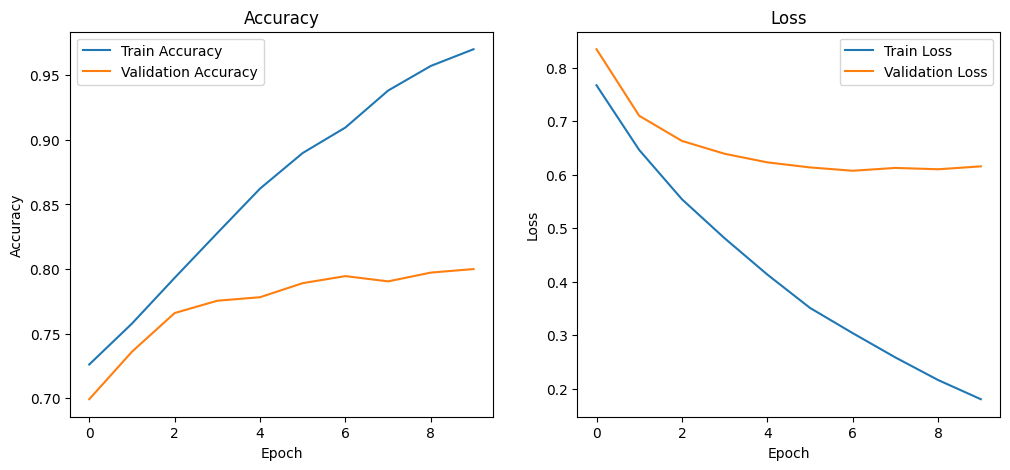

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
model.save("/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/dr_model.keras")

In [15]:
import os

print(os.path.exists("/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/dr_model.keras"))

True


In [16]:
import os

img_path = "/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/test.jpg"

print(os.path.exists(img_path))

True


In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/test.jpg"

img = image.load_img(img_path, target_size=(224,224))
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)

img = tf.keras.applications.inception_v3.preprocess_input(img)

prediction = model.predict(img)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)*100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence,2),"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Prediction: Proliferate_DR
Confidence: 34.21 %


In [18]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if "dr_model" in f:
            print(os.path.join(root, f))

/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/dr_model.keras


In [23]:
req = """streamlit
tensorflow
numpy
pillow
"""

with open("/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/requirements.txt","w") as f:
    f.write(req)

print("requirements.txt created!")

requirements.txt created!


In [24]:
!pip install streamlit -q
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [25]:
!streamlit run app.py & npx localtunnel --port 8501

⠙Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
⠹⠸⠼⠴your url is: https://red-foxes-dream.loca.lt
^C


In [26]:
!streamlit run /content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/app.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴⠦your url is: https://two-moons-beg.loca.lt
2026-07-02 11:35:23.025 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.224.93:8501

  Stopping...
^C


In [27]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

--2026-07-02 11:37:45--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.6.1/cloudflared-linux-amd64.deb [following]
--2026-07-02 11:37:45--  https://github.com/cloudflare/cloudflared/releases/download/2026.6.1/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/7e5346eb-2435-4634-bcbb-e4e22e283cd7?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-02T12%3A18%3A19Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64.deb&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b

In [28]:
!streamlit run /content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/app.py &
!cloudflared tunnel --url http://localhost:8501



2026-07-02 11:38:03.580 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.224.93:8501

  Stopping...
2026-07-02T11:39:14Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-02T11:39:14Z INF Requesting new quick Tunnel on trycloudflare.com...
^C


In [30]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/dr_model.keras"
)

class_names = [
    "Mild",
    "Moderate",
    "No_DR",
    "Proliferative_DR",
    "Severe"
]

def predict(image):
    img = image.resize((224, 224))
    img = np.array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.inception_v3.preprocess_input(img)

    pred = model.predict(img, verbose=0)[0]

    index = np.argmax(pred)
    confidence = float(np.max(pred) * 100)

    return {
        class_names[i]: float(pred[i])
        for i in range(len(class_names))
    }, f"Prediction: {class_names[index]}\nConfidence: {confidence:.2f}%"

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Retinal Image"),
    outputs=[
        gr.Label(num_top_classes=5, label="Prediction Probabilities"),
        gr.Textbox(label="Result")
    ],
    title="🩺 Diabetic Retinopathy Detection",
    description="Upload a retinal image to predict the stage of diabetic retinopathy using an InceptionV3 model."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3709a7b9c4227db192.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
